# 03 — Classification: High-Value Customer Prediction

Implements **Section 5.1–5.2** of the project spec.

**Pipeline dependency:** this notebook requires the following artifacts from `01_data_preprocessing.ipynb`:
- `data/customer_features_classification.csv` — full-year customer features
- `models/customer_split_ids.pkl` — the **official 80/10/10** customer-level split (Section 5.1)

The split is **not** re-created here. It is loaded as-is from notebook 01, ensuring that the
exact same customers are used for training, validation, and testing across `02_pca_lda.ipynb`,
this notebook, `04_regression.ipynb`, and the Phase 3 notebook.

**Baseline classifier note (Section 4.4):** `src/models.py::get_baseline_classifier()` returns
`LogisticRegression(solver="liblinear", random_state=42)` — the same untuned configuration
used by `02_pca_lda.ipynb` for the feature comparison table. In this notebook, that same
configuration is the **starting point** for Model 2 before applying 5-fold cross-validated
GridSearchCV tuning.

In [1]:
# --- Imports ---
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load the customer feature table (from `01_data_preprocessing.ipynb`)

In [2]:
CUSTOMER_FEATURES_PATH = DATA_DIR / "customer_features_classification.csv"

if not CUSTOMER_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"customer_features_classification.csv not found at {CUSTOMER_FEATURES_PATH}.\n"
        "Please run 01_data_preprocessing.ipynb first."
    )

customer_df = pd.read_csv(CUSTOMER_FEATURES_PATH)
print(f"Loaded {len(customer_df):,} customers with columns: {list(customer_df.columns)}")
customer_df.head()

Loaded 4,338 customers with columns: ['CustomerID', 'Monetary', 'Frequency', 'Product_Diversity', 'Recency', 'Avg_Spend_Trans', 'Homeware', 'Stationery', 'Gadgets', 'Decorations', 'Kitchenware', 'Other']


,CustomerID,Monetary,Frequency,Product_Diversity,Recency,Avg_Spend_Trans,Homeware,Stationery,Gadgets,Decorations,Kitchenware,Other
0,12346,77183.60,1,1,326,77183.600000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000
1,12347,4310.00,7,103,2,615.714286,1.728074,11.770302,20.121578,0.236659,11.445476,54.697912
2,12348,1797.24,4,22,75,449.310000,0.000000,23.035321,0.000000,3.538759,15.023035,58.402884
3,12349,1757.55,1,73,19,1757.550000,8.145430,0.443800,2.691246,1.433814,18.125231,69.160479
4,12350,334.40,1,17,310,334.400000,0.000000,0.000000,0.000000,0.000000,11.842105,88.157895


## 2. Load the official 80/10/10 split (Section 5.1)

The split was generated once in `01_data_preprocessing.ipynb` and is loaded here unchanged.
Loading rather than re-generating guarantees that `02_pca_lda.ipynb`, this notebook,
`04_regression.ipynb`, and Phase 3 all operate on the **same** train / validation / test customers.

In [3]:
SPLIT_PATH = MODELS_DIR / "customer_split_ids.pkl"

if not SPLIT_PATH.exists():
    raise FileNotFoundError(
        f"customer_split_ids.pkl not found at {SPLIT_PATH}.\n"
        "Please run 01_data_preprocessing.ipynb first to generate the official 80/10/10 split."
    )

split_data = joblib.load(SPLIT_PATH)
train_ids  = split_data["train_ids"]
val_ids    = split_data["val_ids"]
test_ids   = split_data["test_ids"]

train_df = customer_df[customer_df["CustomerID"].isin(train_ids)].reset_index(drop=True)
val_df   = customer_df[customer_df["CustomerID"].isin(val_ids)].reset_index(drop=True)
test_df  = customer_df[customer_df["CustomerID"].isin(test_ids)].reset_index(drop=True)

n_total = len(customer_df)
print(f"Loaded official 80/10/10 split from {SPLIT_PATH}")
print(f"Train: {len(train_df)} ({len(train_df)/n_total:.1%})  |  "
      f"Val: {len(val_df)} ({len(val_df)/n_total:.1%})  |  "
      f"Test: {len(test_df)} ({len(test_df)/n_total:.1%})")

Loaded official 80/10/10 split from ..\models\customer_split_ids.pkl
Train: 3470 (80.0%)  |  Val: 434 (10.0%)  |  Test: 434 (10.0%)


## 3. High-Value label (Sections 4.1 / 5.2)

Top-20% Monetary threshold computed on the **training split only**, then applied unchanged to
validation and test.

In [4]:
monetary_threshold = train_df["Monetary"].quantile(0.80)
print(f"High-Value threshold (80th percentile of TRAIN Monetary): {monetary_threshold:.2f}")

for split_df, name in [(train_df, "train"), (val_df, "validation"), (test_df, "test")]:
    split_df["High_Value"] = (split_df["Monetary"] > monetary_threshold).astype(int)
    print(f"{name:>10}: {split_df['High_Value'].mean():.1%} High-Value "
          f"({split_df['High_Value'].sum()} / {len(split_df)})")

# Save the canonical threshold — used by app.py and any other notebook that needs it.
joblib.dump(monetary_threshold, MODELS_DIR / "high_value_threshold.pkl")

High-Value threshold (80th percentile of TRAIN Monetary): 2116.83
     train: 20.0% High-Value (694 / 3470)
validation: 14.7% High-Value (64 / 434)
      test: 18.2% High-Value (79 / 434)


['..\\models\\high_value_threshold.pkl']

## 4. Feature selection

**Important modeling decision:** `Monetary` is excluded from the input features. `High_Value` is
*defined* as a threshold on `Monetary`, so including `Monetary` as a predictor would make the
classification task circular — a model could get near-perfect accuracy by learning the threshold
itself rather than learning any genuinely useful customer-behavior pattern. This would also be
pointless to report, since it isn't really "prediction" in any useful sense.

Input features used: `Recency`, `Frequency`, `Product_Diversity`, `Avg_Spend_Trans`, and the 5
category-spend-percentage features (`Other` dropped.

In [5]:
FEATURE_COLUMNS = [
    "Recency", "Frequency", "Product_Diversity", "Avg_Spend_Trans",
    "Homeware", "Stationery", "Gadgets", "Decorations", "Kitchenware",
]

X_train = train_df[FEATURE_COLUMNS].values
X_val   = val_df[FEATURE_COLUMNS].values
X_test  = test_df[FEATURE_COLUMNS].values

y_train = train_df["High_Value"].values
y_val   = val_df["High_Value"].values
y_test  = test_df["High_Value"].values

# Standardize -- fit on TRAIN only, apply the same transform to val/test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, MODELS_DIR / "scaler_classification.pkl")
print(f"Feature matrix shapes -- train: {X_train_scaled.shape}, val: {X_val_scaled.shape}, test: {X_test_scaled.shape}")

Feature matrix shapes -- train: (3470, 9), val: (434, 9), test: (434, 9)


## 5. Model 2: Logistic Regression — why this over Random Forest

This project uses **Logistic Regression**, for four concrete reasons:

1. **It's required by Section 4.4, and already implemented.** Section 4.4 says the PCA/LDA
   comparison must reuse "the SAME classifier (Model 2 baseline from Phase 2)".
2. **Genuine linear-vs-nonlinear contrast.** Model 1 (the FFNN) is already a nonlinear model. Random
   Forest is *also* nonlinear, so a Random Forest baseline would tell us less about *why* one model
   outperforms another (nonlinear vs nonlinear, harder to attribute the difference to model
   capacity). Logistic Regression gives a clean linear reference point against which to judge how
   much the FFNN's nonlinearity is actually buying us on this data.
3. **Interpretability for the business use case.** Section 2 frames this as a marketing decision
   tool. Logistic
   Regression's coefficients translate directly into "this feature increases/decreases the odds of
   being High-Value by X", which is far easier to defend to a non-technical marketing stakeholder
   than a Random Forest's feature importances.
4. **Consistency across the whole report.** The regression task (Section 5.3) also uses a linear
   baseline (Linear Regression). Using Logistic Regression here keeps a single "linear baseline
   family" story running through Phases 1–2.

**Baseline configuration:** `LogisticRegression(solver="liblinear", random_state=42)` — identical
to `get_baseline_classifier()` in `src/models.py`. This is the starting point; below it is tuned
with 5-fold GridSearchCV to find the best `C` and `penalty`.

## 6. Hyperparameter tuning — 5-fold CV on the TRAINING set only (Section 5.2)

Both models are tuned with `GridSearchCV` (5-fold CV, scored on F1 since `High_Value` is imbalanced
~20/80) using **only** the training data. The validation set is not touched here.

In [ ]:
# --- Model 2: Logistic Regression ---
# Starting from the baseline Logistic Regression model, we will tune hyperparameters by grid search 
# over a range of values for the regularization strength C and the penalty type (L1 vs L2),
logreg_param_grid = {
    "C":       [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
}
logreg_grid = GridSearchCV(
    LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE),
    logreg_param_grid, cv=5, scoring="f1", n_jobs=-1,
)
logreg_grid.fit(X_train_scaled, y_train)

model2_logreg = logreg_grid.best_estimator_
print("Best Logistic Regression params:", logreg_grid.best_params_)
print(f"Best CV F1 (train-only): {logreg_grid.best_score_:.4f}")

Best Logistic Regression params: {'C': 100, 'penalty': 'l1'}
Best CV F1 (train-only): 0.8366


c:\Users\ua510\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ua510\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [7]:
# --- Model 1: Feed-forward neural network (MLPClassifier) ---
# Architecture is fixed per spec: input -> Dense(32, ReLU) -> Dense(16, ReLU) -> Dense(1, Sigmoid).
# sklearn's MLPClassifier automatically uses a single logistic (sigmoid) output unit for binary
# targets, so hidden_layer_sizes=(32, 16) with activation="relu" matches this exactly.
# Tuning is limited to regularization (alpha) and learning rate, keeping the architecture itself
# at the spec's minimum.
mlp_param_grid = {
    "alpha":                [0.0001, 0.001, 0.01],
    "learning_rate_init":   [0.001, 0.01],
}
mlp_grid = GridSearchCV(
    MLPClassifier(
        hidden_layer_sizes=(32, 16), activation="relu", solver="adam",
        max_iter=1000, random_state=RANDOM_STATE,
    ),
    mlp_param_grid, cv=5, scoring="f1", n_jobs=-1,
)
mlp_grid.fit(X_train_scaled, y_train)

model1_ffnn = mlp_grid.best_estimator_
print("Best FFNN params:", mlp_grid.best_params_)
print(f"Best CV F1 (train-only): {mlp_grid.best_score_:.4f}")

Best FFNN params: {'alpha': 0.0001, 'learning_rate_init': 0.01}
Best CV F1 (train-only): 0.9600


## 7. Validation set — pick the final model (Section 5.2)

The validation set is used **once**, after tuning, purely to choose between the two already-tuned
models. It plays no role in hyperparameter selection.

In [8]:
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
    }

val_results = {
    "Model 1 (FFNN)":                compute_metrics(y_val, model1_ffnn.predict(X_val_scaled)),
    "Model 2 (Logistic Regression)": compute_metrics(y_val, model2_logreg.predict(X_val_scaled)),
}
val_comparison = pd.DataFrame(val_results).T.round(4)
print("Validation-set comparison (used once, to select the final model):")
display(val_comparison)

final_model_name = val_comparison["F1"].idxmax()
final_model = model1_ffnn if final_model_name == "Model 1 (FFNN)" else model2_logreg
print(f"\nSelected final model based on validation F1: {final_model_name}")

Validation-set comparison (used once, to select the final model):


,Accuracy,Precision,Recall,F1
Model 1 (FFNN),0.9885,0.9683,0.9531,0.9606
Model 2 (Logistic Regression),0.9585,0.8833,0.8281,0.8548



Selected final model based on validation F1: Model 1 (FFNN)


## 8. Test set — touched exactly once (Section 5.2)

The spec asks for metrics on **both** models but also says the
test set is "touched exactly once, at the very end." These aren't in conflict: the test set is
never used for tuning or for model selection (that already happened on validation, above) — it is
evaluated in a single pass here, computing both models' final metrics together, which counts as
one "touch".

In [9]:
test_results = {
    "Model 1 (FFNN)":                compute_metrics(y_test, model1_ffnn.predict(X_test_scaled)),
    "Model 2 (Logistic Regression)": compute_metrics(y_test, model2_logreg.predict(X_test_scaled)),
}
test_comparison = pd.DataFrame(test_results).T.round(4)
test_comparison.to_csv(MODELS_DIR / "classification_test_comparison.csv")
print("Final test-set comparison (this cell is the single test-set evaluation):")
test_comparison

Final test-set comparison (this cell is the single test-set evaluation):


,Accuracy,Precision,Recall,F1
Model 1 (FFNN),0.9908,0.9870,0.9620,0.9744
Model 2 (Logistic Regression),0.9447,0.8767,0.8101,0.8421


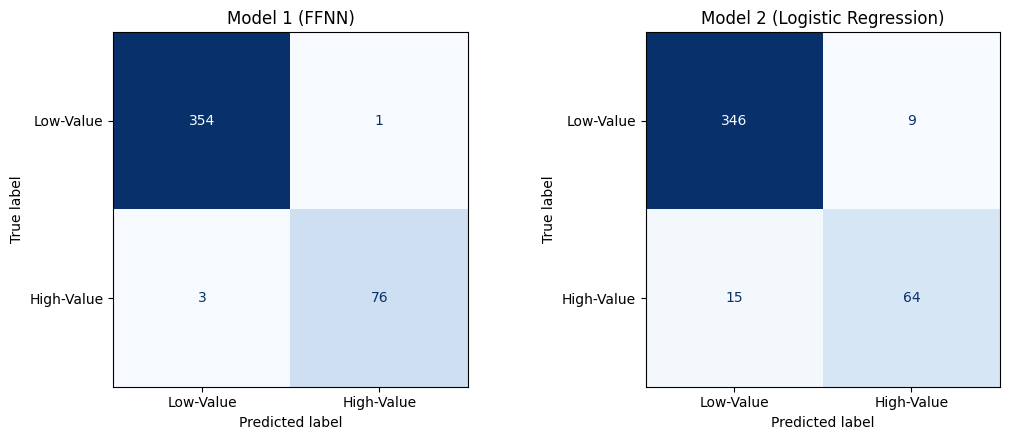

In [10]:
# Confusion matrices for both models, on the test set.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, model) in zip(axes, [("Model 1 (FFNN)", model1_ffnn), ("Model 2 (Logistic Regression)", model2_logreg)]):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low-Value", "High-Value"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.savefig(MODELS_DIR / "classification_confusion_matrices.png", dpi=150)
plt.show()

## 9. Save model artifacts

In [11]:
joblib.dump(model1_ffnn,   MODELS_DIR / "model1_ffnn_classifier.pkl")
joblib.dump(model2_logreg, MODELS_DIR / "model2_logreg_classifier.pkl")
joblib.dump(final_model,   MODELS_DIR / "final_classification_model.pkl")

with open(MODELS_DIR / "classification_model_selection.json", "w") as f:
    json.dump({
        "selected_model":     final_model_name,
        "selection_metric":   "F1 (validation set)",
        "validation_scores":  val_comparison.to_dict(orient="index"),
        "test_scores":        test_comparison.to_dict(orient="index"),
        "feature_columns":    FEATURE_COLUMNS,
        "monetary_threshold": float(monetary_threshold),
    }, f, indent=2)

print("Saved model artifacts to models/:")
print(" - model1_ffnn_classifier.pkl")
print(" - model2_logreg_classifier.pkl")
print(f" - final_classification_model.pkl  (= {final_model_name})")
print(" - classification_model_selection.json")

Saved model artifacts to models/:
 - model1_ffnn_classifier.pkl
 - model2_logreg_classifier.pkl
 - final_classification_model.pkl  (= Model 1 (FFNN))
 - classification_model_selection.json


## 10. Artifacts saved by this notebook

| File | Description |
|---|---|
| `models/high_value_threshold.pkl` | The canonical High-Value threshold (80th pct of train Monetary) |
| `models/scaler_classification.pkl` | `StandardScaler` fit on the 9 input features (train only) |
| `models/model1_ffnn_classifier.pkl` | Tuned FFNN (best params from 5-fold CV) |
| `models/model2_logreg_classifier.pkl` | Tuned Logistic Regression (best params from 5-fold CV) |
| `models/final_classification_model.pkl` | Model selected by validation-set F1 |
| `models/classification_model_selection.json` | Selected model name, val & test scores, features, threshold |
| `models/classification_test_comparison.csv` | Final test-set metrics for both models |
| `models/classification_confusion_matrices.png` | Confusion matrices for the report |

**Next notebook:** `04_regression.ipynb` should load `models/customer_split_ids.pkl` to reuse the
identical train/val/test customers, and load `data/customer_features_regression.csv` (which uses
months 1–9 features + months 10–12 target to avoid data leakage), per Section 5.1 and 5.3.